
===== IRIS DATASET METRICS =====
Accuracy: 0.9777777777777777
Precision: 0.9761904761904763
Recall: 0.9743589743589745
F1 Score: 0.974320987654321


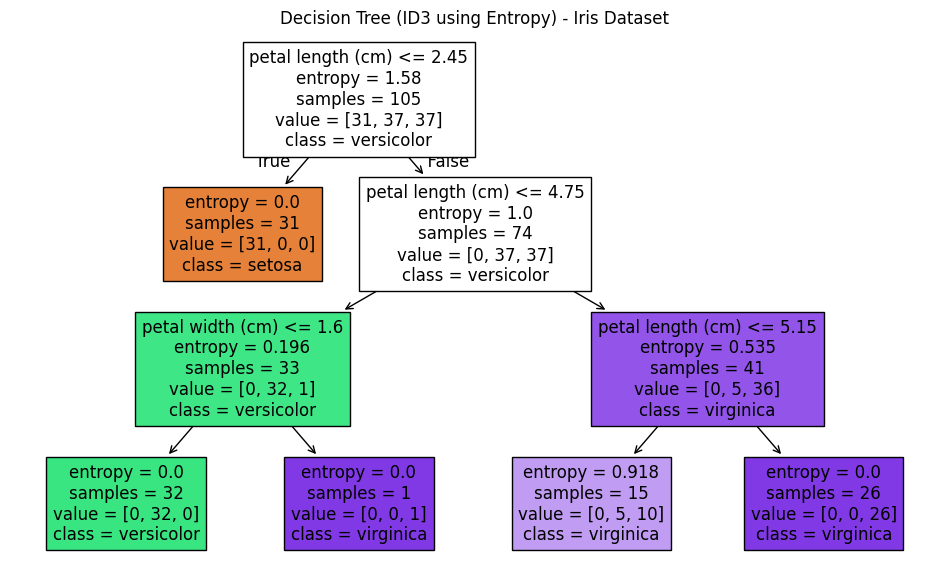


===== BREAST CANCER METRICS =====
Accuracy: 0.9590643274853801
Precision: 0.954954954954955
Recall: 0.9814814814814815
F1 Score: 0.9680365296803652


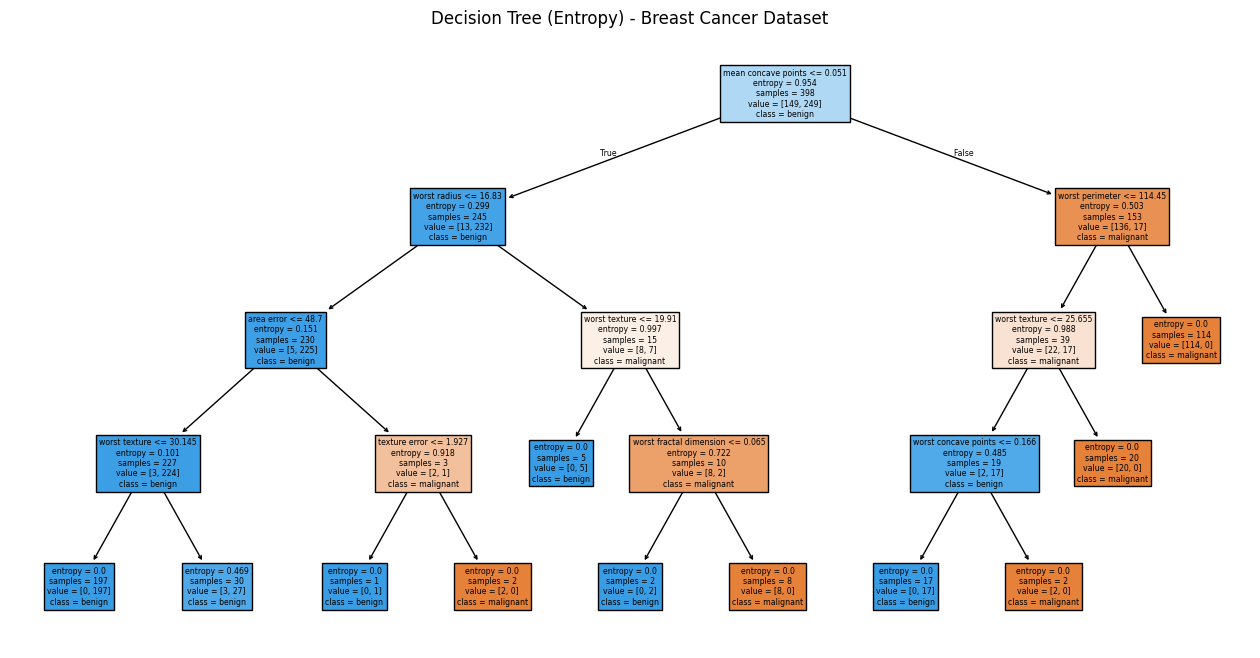


===== DIABETES REGRESSION METRICS =====
MSE: 3649.4238895890826
RMSE: 60.410461756131966
MAE: 47.94435792736553
R2 Score: 0.3239689083020818


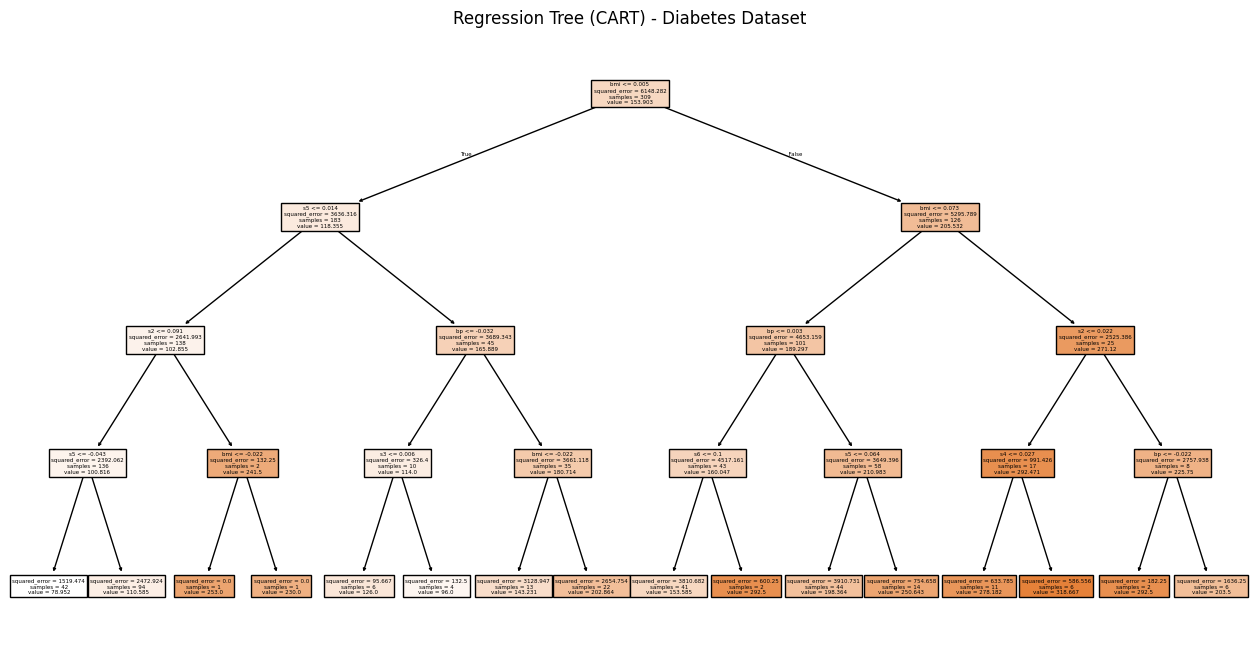

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ==============================
# 1. IRIS DATASET (Entropy - Classification)
# ==============================

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

clf = DecisionTreeClassifier(
    criterion="entropy",   # ID3 style
    max_depth=3,
    random_state=42
)

clf.fit(X_train, y_train)

pred = clf.predict(X_test)

print("\n===== IRIS DATASET METRICS =====")
print("Accuracy:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred, average='macro'))
print("Recall:", recall_score(y_test, pred, average='macro'))
print("F1 Score:", f1_score(y_test, pred, average='macro'))

# Tree Visualization
plt.figure(figsize=(12,7))
plot_tree(
    clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)
plt.title("Decision Tree (ID3 using Entropy) - Iris Dataset")
plt.show()



# ==============================
# 2. BREAST CANCER DATASET
# ==============================

cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

clf2 = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

clf2.fit(X_train, y_train)

pred = clf2.predict(X_test)

print("\n===== BREAST CANCER METRICS =====")
print("Accuracy:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall:", recall_score(y_test, pred))
print("F1 Score:", f1_score(y_test, pred))

# Tree Visualization
plt.figure(figsize=(16,8))
plot_tree(
    clf2,
    feature_names=cancer.feature_names,
    class_names=cancer.target_names,
    filled=True
)
plt.title("Decision Tree (Entropy) - Breast Cancer Dataset")
plt.show()



# ==============================
# 3. DIABETES DATASET (CART Regression)
# ==============================

diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

reg = DecisionTreeRegressor(
    criterion="squared_error",  # CART regression
    max_depth=4,
    random_state=42
)

reg.fit(X_train, y_train)

pred = reg.predict(X_test)

print("\n===== DIABETES REGRESSION METRICS =====")

mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mean_absolute_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))


# Regression Tree Visualization
plt.figure(figsize=(16,8))
plot_tree(
    reg,
    feature_names=diabetes.feature_names,
    filled=True
)
plt.title("Regression Tree (CART) - Diabetes Dataset")
plt.show()

MSE: 25.0
RMSE: 5.0
MAE: 5.0
R2 Score: nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


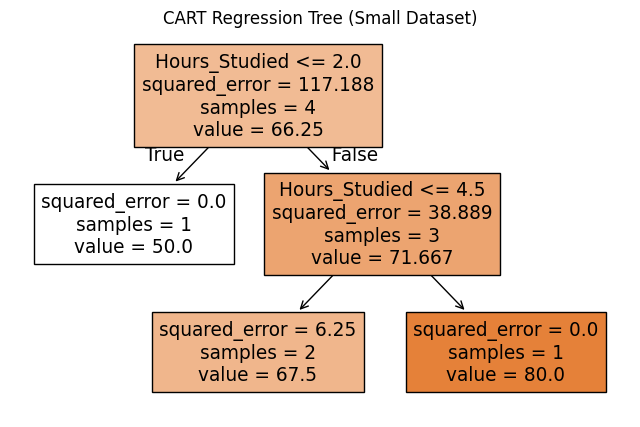

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ---------------------------------------------------
# Small Dataset (Hours studied vs Exam score)
# ---------------------------------------------------

X = np.array([[1],
              [2],
              [3],
              [4],
              [5]])

y = np.array([50, 55, 65, 70, 80])


# ---------------------------------------------------
# Train/Test Split
# ---------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ---------------------------------------------------
# CART Regression Tree
# ---------------------------------------------------

model = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=2,
    random_state=42
)

model.fit(X_train, y_train)


# ---------------------------------------------------
# Predictions
# ---------------------------------------------------

pred = model.predict(X_test)


# ---------------------------------------------------
# Regression Metrics
# ---------------------------------------------------

mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mean_absolute_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))


# ---------------------------------------------------
# Tree Visualization
# ---------------------------------------------------

plt.figure(figsize=(8,5))

plot_tree(
    model,
    feature_names=["Hours_Studied"],
    filled=True
)

plt.title("CART Regression Tree (Small Dataset)")
plt.show()